# Agent Utilization Overview

Select a run directory and see per-agent breakdown of:
- **Processing time**: time actually working on tasks
- **Waiting time**: time tasks spent in queue (assigned → started)
- **Idle time**: time agent has no work

Compares all methods (variants) in the selected run.

In [36]:
# ── CONFIGURATION ──────────────────────────────────────────────────────────

RUN_PATH = "../../results/runs/cvs/regular/20260301_130635"  # ← change this

# Which phase to analyze
PHASE = "train"  # "train" | "eval" | "final_eval"

# ────────────────────────────────────────────────────────────────────────────

In [37]:
import re
import warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

run_dir = Path(RUN_PATH)
assert run_dir.exists(), f"Run not found: {run_dir.resolve()}"
print(f"Run: {run_dir.resolve()}")

Run: /Users/bjornkoemans/Documents/GitHub/master-cope/results/runs/cvs/regular/20260301_130635


In [38]:
# ── Discover methods and find log files ──

def find_methods(run_dir: Path) -> dict:
    """Discover method directories and their log files."""
    methods = {}
    skip = {"logs", "configs", ".tmp_configs", "__pycache__"}
    
    for d in sorted(run_dir.iterdir()):
        if not d.is_dir() or d.name in skip or d.name.startswith("."):
            continue
        
        # Try phase-specific subdirs first, then fallback
        candidates = [
            (d / "logs" / PHASE, f"log_{PHASE}_ep*_*.csv"),
            (d / "logs" / PHASE, "*.csv"),
            (d / "logs", f"log_{PHASE}_ep*_*.csv"),
        ]
        
        # If phase is final_eval but not found, fall back to eval (MAPPO has eval not final_eval)
        if PHASE == "final_eval":
            candidates += [
                (d / "logs" / "eval", "log_eval_ep*_*.csv"),
                (d / "logs" / "eval", "*.csv"),
            ]
        
        csvs = []
        for log_dir, pattern in candidates:
            if log_dir.exists():
                csvs = sorted(log_dir.glob(pattern))
                if csvs:
                    break
        
        if csvs:
            methods[d.name] = csvs
    
    return methods


methods = find_methods(run_dir)
print(f"Found {len(methods)} methods:")
for name, csvs in methods.items():
    print(f"  {name}: {len(csvs)} log files ({csvs[0].parent.name})")

Found 3 methods:
  baseline_random_collab: 10 log files (train)
  mappo_collab: 8 log files (train)
  mappo_collab_comm: 7 log files (train)


In [39]:
# ── Parse agent utilization from log CSVs ──

def safe_parse_timestamps(series: pd.Series) -> pd.Series:
    """Parse timestamps with mixed precision (0, 6, or 9 decimal places)."""
    s = series.astype(str)
    # Truncate nanoseconds to microseconds: .678260364 → .678260
    s = s.str.replace(r'(\.\d{6})\d+', r'\1', regex=True)
    # Add .000000 to timestamps without fractional seconds: 08:00:00+00:00 → 08:00:00.000000+00:00
    s = s.str.replace(r'(\d{2}:\d{2}:\d{2})(\+)', r'\1.000000\2', regex=True)
    return pd.to_datetime(s, errors="coerce", utc=True)


def expand_collab_agents(df: pd.DataFrame) -> pd.DataFrame:
    """Expand collaborative task rows (agent_id='2|3') into separate rows per agent."""
    agent_col = df["task_agent_id"].astype(str)
    is_collab = agent_col.str.contains("|", regex=False, na=False)
    
    solo = df[~is_collab].copy()
    solo["task_agent_id"] = solo["task_agent_id"].astype(str).str.strip().astype(float).astype(int)
    
    collab = df[is_collab].copy()
    if collab.empty:
        return solo
    
    collab = collab.copy()
    collab["agent_list"] = collab["task_agent_id"].astype(str).str.split("|")
    collab["n_agents"] = collab["agent_list"].apply(len)
    collab["processing_s"] = collab["processing_s"] / collab["n_agents"]
    collab = collab.explode("agent_list")
    collab["task_agent_id"] = collab["agent_list"].astype(int)
    collab = collab.drop(columns=["agent_list", "n_agents"])
    
    return pd.concat([solo, collab], ignore_index=True)


def parse_agent_utilization(csv_files: list, debug=False) -> pd.DataFrame:
    """Parse log CSVs and compute per-agent utilization across all episodes."""
    all_dfs = []
    for f in csv_files:
        try:
            df = pd.read_csv(f, low_memory=False)
        except Exception:
            continue
        if df.empty:
            continue
        all_dfs.append(df)
    
    if not all_dfs:
        return pd.DataFrame()
    
    df = pd.concat(all_dfs, ignore_index=True)
    n_episodes = len(csv_files)
    
    if debug:
        print(f"  Raw rows: {len(df)}, episodes: {n_episodes}")
    
    # Parse timestamps (normalize mixed precision)
    for col in ["task_assigned_time", "task_started_time", "task_completed_time"]:
        if col in df.columns:
            df[col] = safe_parse_timestamps(df[col])
    
    # Per-task metrics
    df["processing_s"] = (df["task_completed_time"] - df["task_started_time"]).dt.total_seconds()
    df["waiting_s"] = (df["task_started_time"] - df["task_assigned_time"]).dt.total_seconds()
    
    # Filter invalid
    before = len(df)
    df = df.dropna(subset=["processing_s", "waiting_s"])
    df = df[df["processing_s"] >= 0]
    df = df[df["waiting_s"] >= 0]
    if debug:
        print(f"  After filter: {len(df)} (dropped {before - len(df)})")
    
    # Expand collaborative agent IDs
    df = expand_collab_agents(df)
    
    if debug:
        print(f"  After expand: {len(df)} rows, agents: {sorted(df['task_agent_id'].unique())}")
    
    # Simulation span per episode (average)
    sim_start = df["task_assigned_time"].min()
    sim_end = df["task_completed_time"].max()
    total_seconds = (sim_end - sim_start).total_seconds()
    per_episode_seconds = total_seconds / n_episodes
    
    # Aggregate per agent
    agent_stats = df.groupby("task_agent_id").agg(
        processing_s=("processing_s", "sum"),
        waiting_s=("waiting_s", "sum"),
        n_tasks=("processing_s", "count"),
    ).reset_index()
    
    # Average per episode
    agent_stats["processing_s"] /= n_episodes
    agent_stats["waiting_s"] /= n_episodes
    agent_stats["n_tasks"] = (agent_stats["n_tasks"] / n_episodes).round(0).astype(int)
    
    # Idle = total episode span - processing time
    agent_stats["total_s"] = per_episode_seconds
    agent_stats["idle_s"] = (agent_stats["total_s"] - agent_stats["processing_s"]).clip(lower=0)
    
    # Convert to minutes
    for col in ["processing_s", "waiting_s", "idle_s", "total_s"]:
        agent_stats[col.replace("_s", "_min")] = agent_stats[col] / 60
    
    agent_stats["utilization_pct"] = (
        agent_stats["processing_s"] / agent_stats["total_s"] * 100
    ).round(1)
    
    return agent_stats[["task_agent_id", "n_tasks", 
                        "processing_min", "waiting_min", "idle_min", "total_min",
                        "utilization_pct"]].sort_values("task_agent_id").reset_index(drop=True)


# Parse all methods
utilization = OrderedDict()
for name, csvs in methods.items():
    print(f"\n── {name} ({len(csvs)} episodes avg) ──")
    stats = parse_agent_utilization(csvs, debug=True)
    if not stats.empty:
        utilization[name] = stats
        display(stats.round(1))


── baseline_random_collab (10 episodes avg) ──
  Raw rows: 679630, episodes: 10
  After filter: 679630 (dropped 0)
  After expand: 848380 rows, agents: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,task_agent_id,n_tasks,processing_min,waiting_min,idle_min,total_min,utilization_pct
0,0,9330,17521.9,169889928.6,108.5,17630.5,99.4
1,1,24560,0.0,0.0,17630.5,17630.5,0.0
2,2,17280,91324.5,284259164.2,0.0,17630.5,518.0
3,3,17256,92845.9,283888779.2,0.0,17630.5,526.6
4,4,16412,93193.5,268663511.6,0.0,17630.5,528.6



── mappo_collab (8 episodes avg) ──
  Raw rows: 543704, episodes: 8
  After filter: 543704 (dropped 0)
  After expand: 678704 rows, agents: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,task_agent_id,n_tasks,processing_min,waiting_min,idle_min,total_min,utilization_pct
0,0,9330,16038.9,171852982.6,6134.7,22173.5,72.3
1,1,24560,0.0,0.0,22173.5,22173.5,0.0
2,2,17645,97411.8,292345581.7,0.0,22173.5,439.3
3,3,16891,86309.4,280403291.0,0.0,22173.5,389.2
4,4,16412,88777.3,272541728.4,0.0,22173.5,400.4



── mappo_collab_comm (7 episodes avg) ──
  Raw rows: 422373, episodes: 7
  After filter: 422373 (dropped 0)
  After expand: 527088 rows, agents: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,task_agent_id,n_tasks,processing_min,waiting_min,idle_min,total_min,utilization_pct
0,0,8266,14319.8,147299970.9,10866.2,25186.0,56.9
1,1,21822,0.0,0.0,25186.0,25186.0,0.0
2,2,15409,80490.6,247551809.1,0.0,25186.0,319.6
3,3,15448,77438.8,248452096.0,0.0,25186.0,307.5
4,4,14353,81887.4,229786706.4,0.0,25186.0,325.1


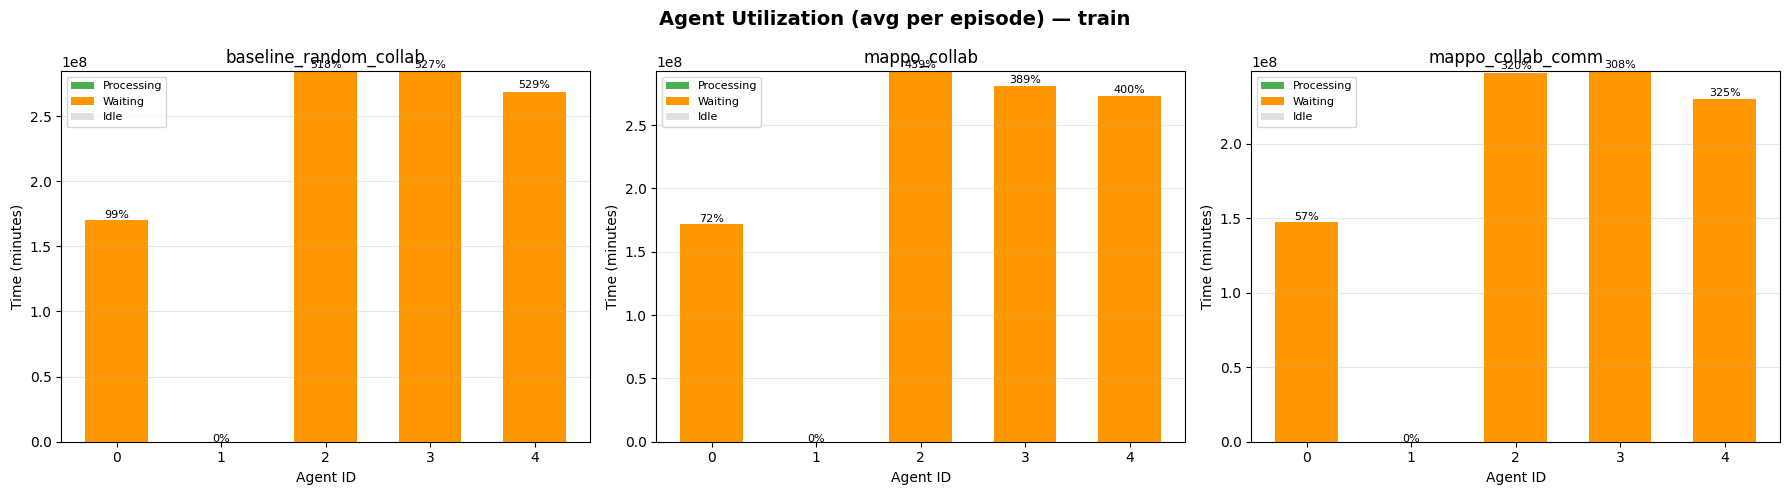

In [40]:
# ── Stacked bar chart: Processing / Waiting / Idle per agent, per method ──

n_methods = len(utilization)
if n_methods == 0:
    print("No data to plot")
else:
    fig, axes = plt.subplots(1, n_methods, figsize=(6 * n_methods, 5), squeeze=False)
    
    for idx, (name, stats) in enumerate(utilization.items()):
        ax = axes[0, idx]
        agents = stats["task_agent_id"].astype(str)
        x = np.arange(len(agents))
        w = 0.6
        
        ax.bar(x, stats["processing_min"], w, label="Processing", color="#4CAF50")
        ax.bar(x, stats["waiting_min"], w, bottom=stats["processing_min"], 
               label="Waiting", color="#FF9800")
        ax.bar(x, stats["idle_min"], w, 
               bottom=stats["processing_min"] + stats["waiting_min"],
               label="Idle", color="#E0E0E0")
        
        # Add utilization % labels on top
        for i, pct in enumerate(stats["utilization_pct"]):
            top = stats["processing_min"].iloc[i] + stats["waiting_min"].iloc[i] + stats["idle_min"].iloc[i]
            ax.text(i, top + top * 0.01, f"{pct:.0f}%", ha="center", fontsize=8)
        
        ax.set_xlabel("Agent ID")
        ax.set_ylabel("Time (minutes)")
        ax.set_title(name)
        ax.set_xticks(x)
        ax.set_xticklabels(agents)
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)
    
    fig.suptitle(f"Agent Utilization (avg per episode) — {PHASE}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [41]:
# ── Case detail view ──

CASE_ID = 0  # ← change to inspect a specific case (None = skip)

if CASE_ID is not None and methods:
    for name, csvs in methods.items():
        # Read first CSV that contains this case
        for f in csvs:
            df = pd.read_csv(f, low_memory=False)
            case_df = df[df["case_id"] == CASE_ID]
            if not case_df.empty:
                break
        
        if case_df.empty:
            print(f"\n── {name}: Case {CASE_ID} not found ──")
            continue
        
        # Parse timestamps
        for col in ["task_assigned_time", "task_started_time", "task_completed_time",
                     "case_open_time", "case_completed_time"]:
            if col in case_df.columns:
                case_df[col] = pd.to_datetime(case_df[col], errors="coerce")
        
        # Compute per-task times
        case_df = case_df.copy()
        case_df["waiting_s"] = (case_df["task_started_time"] - case_df["task_assigned_time"]).dt.total_seconds()
        case_df["processing_s"] = (case_df["task_completed_time"] - case_df["task_started_time"]).dt.total_seconds()
        case_df["total_s"] = (case_df["task_completed_time"] - case_df["task_assigned_time"]).dt.total_seconds()
        
        # Case-level summary
        case_open = case_df["case_open_time"].iloc[0] if "case_open_time" in case_df.columns else case_df["task_assigned_time"].min()
        case_done = case_df["case_completed_time"].iloc[0] if "case_completed_time" in case_df.columns else case_df["task_completed_time"].max()
        throughput_s = (case_done - case_open).total_seconds()
        
        print(f"\\n── {name}: Case {CASE_ID} ──")\
        
        print(f"  Case open:      {case_open}")
        print(f"  Case completed: {case_done}")
        print(f"  Throughput:     {throughput_s/60:.1f} min ({throughput_s:.0f}s)")
        print(f"  Total waiting:  {case_df['waiting_s'].sum()/60:.1f} min")
        print(f"  Total processing: {case_df['processing_s'].sum()/60:.1f} min")
        print()
        
        # Show task-level detail
        cols = ["task_id"]
        if "task_name" in case_df.columns:
            cols.append("task_name")
        cols += ["task_agent_id", "task_assigned_time", "task_started_time", 
                 "task_completed_time", "waiting_s", "processing_s"]
        if "task_assignment_type" in case_df.columns:
            cols.append("task_assignment_type")
        
        display(case_df[cols].reset_index(drop=True))

\n── baseline_random_collab: Case 0 ──
  Case open:      2019-03-25 08:00:00+00:00
  Case completed: 2019-03-25 08:11:13.255545165+00:00
  Throughput:     11.2 min (673s)
  Total waiting:  0.0 min
  Total processing: 1.5 min



/var/folders/cn/swk31v1j7rxb_0ch62ts2n_h0000gn/T/ipykernel_64227/3852294556.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  case_df[col] = pd.to_datetime(case_df[col], errors="coerce")
/var/folders/cn/swk31v1j7rxb_0ch62ts2n_h0000gn/T/ipykernel_64227/3852294556.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  case_df[col] = pd.to_datetime(case_df[col], errors="coerce")
/var/folders/cn/swk31v1j7rxb_0ch62ts2n_h0000gn/T/ipykernel_64227/3852294556.py:22: SettingWithCopyWarning: 
A value is trying to be 

,task_id,task_name,task_agent_id,task_assigned_time,task_started_time,task_completed_time,waiting_s,processing_s,task_assignment_type
0,9,Process drop-off,4,2019-03-25 08:00:00+00:00,2019-03-25 08:00:00+00:00,2019-03-25 08:01:32.678260364+00:00,0.0,92.67826,solo_fallback_random
1,6,Enter prescription details,4,NaT,NaT,2019-03-25 08:04:18.795282552+00:00,NaN,NaN,solo_volunteer
2,3,Check if refill is allowed,1,NaT,NaT,2019-03-25 08:04:18.795282552+00:00,NaN,NaN,solo_volunteer
3,0,Check DUR,1,NaT,NaT,2019-03-25 08:04:18.795282552+00:00,NaN,NaN,solo_fallback_random
4,7,Pack the drugs (Production),4|3,NaT,NaT,2019-03-25 08:07:20.066737054+00:00,NaN,NaN,collab_fallback_random
5,1,Check Insurance,1,NaT,NaT,2019-03-25 08:07:20.066737054+00:00,NaN,NaN,solo_fallback_random
6,2,Check for Quality Assurance,0|2,NaT,NaT,2019-03-25 08:08:20.597378519+00:00,NaN,NaN,collab_volunteer_partial_random
7,8,Pick-up,4,NaT,NaT,2019-03-25 08:11:13.255545165+00:00,NaN,NaN,solo_volunteer_random


\n── mappo_collab: Case 0 ──
  Case open:      2019-03-25 08:00:00+00:00
  Case completed: 2019-03-25 08:10:37.132535429+00:00
  Throughput:     10.6 min (637s)
  Total waiting:  0.0 min
  Total processing: 1.5 min



/var/folders/cn/swk31v1j7rxb_0ch62ts2n_h0000gn/T/ipykernel_64227/3852294556.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  case_df[col] = pd.to_datetime(case_df[col], errors="coerce")
/var/folders/cn/swk31v1j7rxb_0ch62ts2n_h0000gn/T/ipykernel_64227/3852294556.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  case_df[col] = pd.to_datetime(case_df[col], errors="coerce")
/var/folders/cn/swk31v1j7rxb_0ch62ts2n_h0000gn/T/ipykernel_64227/3852294556.py:22: SettingWithCopyWarning: 
A value is trying to be 

,task_id,task_name,task_agent_id,task_assigned_time,task_started_time,task_completed_time,waiting_s,processing_s,task_assignment_type
0,9,Process drop-off,2,2019-03-25 08:00:00+00:00,2019-03-25 08:00:00+00:00,2019-03-25 08:01:32.412110155+00:00,0.0,92.41211,solo_volunteer
1,6,Enter prescription details,2,NaT,NaT,2019-03-25 08:03:54.656800559+00:00,NaN,NaN,solo_volunteer
2,3,Check if refill is allowed,1,NaT,NaT,2019-03-25 08:03:54.656800559+00:00,NaN,NaN,solo_volunteer
3,0,Check DUR,1,NaT,NaT,2019-03-25 08:03:54.656800559+00:00,NaN,NaN,solo_volunteer
4,7,Pack the drugs (Production),2|3,NaT,NaT,2019-03-25 08:06:43.734616118+00:00,NaN,NaN,collab_volunteer
5,1,Check Insurance,1,NaT,NaT,2019-03-25 08:06:43.734616118+00:00,NaN,NaN,solo_fallback_random
6,2,Check for Quality Assurance,0|3,NaT,NaT,2019-03-25 08:07:43.671387624+00:00,NaN,NaN,collab_volunteer_partial_random
7,8,Pick-up,2,NaT,NaT,2019-03-25 08:10:37.132535429+00:00,NaN,NaN,solo_volunteer


\n── mappo_collab_comm: Case 0 ──
  Case open:      2019-03-25 08:00:00+00:00
  Case completed: 2019-03-25 08:12:49.834382948+00:00
  Throughput:     12.8 min (770s)
  Total waiting:  0.0 min
  Total processing: 1.5 min



/var/folders/cn/swk31v1j7rxb_0ch62ts2n_h0000gn/T/ipykernel_64227/3852294556.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  case_df[col] = pd.to_datetime(case_df[col], errors="coerce")
/var/folders/cn/swk31v1j7rxb_0ch62ts2n_h0000gn/T/ipykernel_64227/3852294556.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  case_df[col] = pd.to_datetime(case_df[col], errors="coerce")
/var/folders/cn/swk31v1j7rxb_0ch62ts2n_h0000gn/T/ipykernel_64227/3852294556.py:22: SettingWithCopyWarning: 
A value is trying to be 

,task_id,task_name,task_agent_id,task_assigned_time,task_started_time,task_completed_time,waiting_s,processing_s,task_assignment_type
0,9,Process drop-off,4,2019-03-25 08:00:00+00:00,2019-03-25 08:00:00+00:00,2019-03-25 08:01:32.678260364+00:00,0.0,92.67826,solo_volunteer
1,6,Enter prescription details,4,NaT,NaT,2019-03-25 08:03:54.904652193+00:00,NaN,NaN,solo_volunteer
2,3,Check if refill is allowed,1,NaT,NaT,2019-03-25 08:03:54.904652193+00:00,NaN,NaN,solo_fallback_random
3,0,Check DUR,1,NaT,NaT,2019-03-25 08:03:54.904652193+00:00,NaN,NaN,solo_volunteer
4,7,Pack the drugs (Production),3|4,NaT,NaT,2019-03-25 08:08:00.176821753+00:00,NaN,NaN,collab_volunteer
5,1,Check Insurance,1,NaT,NaT,2019-03-25 08:08:00.176821753+00:00,NaN,NaN,solo_fallback_random
6,2,Check for Quality Assurance,0|3,NaT,NaT,2019-03-25 08:10:30.733801797+00:00,NaN,NaN,collab_volunteer_partial_random
7,8,Pick-up,2,NaT,NaT,2019-03-25 08:12:49.834382948+00:00,NaN,NaN,solo_volunteer


In [42]:
# ── Summary comparison table across methods ──

summary_rows = []
for name, stats in utilization.items():
    summary_rows.append({
        "Method": name,
        "Agents": len(stats),
        "Total tasks": int(stats["n_tasks"].sum()),
        "Avg processing (min)": stats["processing_min"].mean(),
        "Avg waiting (min)": stats["waiting_min"].mean(),
        "Avg idle (min)": stats["idle_min"].mean(),
        "Avg utilization %": stats["utilization_pct"].mean(),
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    print("\n── Summary across methods ──")
    display(summary_df.round(1))


── Summary across methods ──


,Method,Agents,Total tasks,Avg processing (min),Avg waiting (min),Avg idle (min),Avg utilization %
0,baseline_random_collab,5,84838,58977.1,201340276.7,3547.8,334.5
1,mappo_collab,5,84838,57707.5,203428716.8,5661.6,260.2
2,mappo_collab_comm,5,75298,50827.3,174618116.5,7210.4,201.8
